This notebook tires to find out HSE conditions for LMC. Fail.

In [18]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [19]:
from astropy import units as un, constants as cons
import numpy as np
import cooling_flow as CF
import HaloPotential as Halo
import matplotlib.pyplot as plt
import GrackleCooling as Cool
import AgoraPotential as Agora
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import glob,h5py
from scipy.interpolate import RegularGridInterpolator
from pathlib import Path
import math

In [20]:
plt.rcParams['font.size']=22
plt.rcParams['axes.linewidth']=2
plt.rcParams['xtick.major.size']=10
plt.rcParams['xtick.minor.size']=5
plt.rcParams['xtick.major.width']=2
plt.rcParams['xtick.minor.width']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.major.size']=10
plt.rcParams['ytick.minor.size']=5
plt.rcParams['ytick.major.width']=2
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.direction']='in'

In [21]:
cloudy_H_mass_fraction = 1. / (1. + 0.1 * 3.971)
X = cloudy_H_mass_fraction
Z = 0.02  # metal fraction by mass
Y = 1. - X - Z
mean_metals_A = 16.  # mean atomic weight of metals
sigma_T = 6.6524e-25  
electron_mass_cgs = 9.1093897e-28  # electron mass (g)
mu = 0.6
m_H = 1.672623e-24  # g
T_cmb = 2.725  # * (1 + z); // K
c_light_cgs_ = 2.99792458e10  # cgs
radiation_constant_cgs_ = 7.5646e-15  # cgs
boltzmann_constant_cgs_ = 1.380658e-16  # cgs

In [22]:
Msun = 1.988409870698051e+33
G = 6.674299999999999e-08
mp = 1.67262192369e-24
kpc = 3.0856775814913673e+21
gamma = 5./3.
yr_to_sec = 3.154e+7
Myr = yr_to_sec * 1.e6
kmps = 1.e5
kb = 1.38e-16
mu = 0.6

In [23]:
class Galaxy:
    def __init__(self, galtype):
        self.galtype = galtype.upper()

        if self.galtype == "LMC":
            self.Mvir = 1.775e11 * cons.M_sun   # LMC mass from Shah+
            self.potential = Halo.NFW(Mvir=self.Mvir, z=0, cvir=10)
            self.Z2Zsun = 0.5
            self.Rvir  = self.potential.rvir().value
            self.Thalo = 1.e6

        elif self.galtype == "MW":
            self.Mvir = 1.074e12 * cons.M_sun   # MW mass (AGORA)
            self.potential = Halo.NFW(Mvir=self.Mvir, z=0, cvir=10)
            self.Z2Zsun = 1.0
            self.Rvir  = self.potential.rvir().value
            self.Thalo = 1.e6
            

        else:
            raise ValueError(f"Unknown galaxy type: {galtype}. Use 'LMC' or 'MW'.")

        # Derived quantities
        self.rvir = self.potential.rvir()
        self.vc200 = self.potential.vc(self.rvir)


In [24]:
gal = Galaxy("LMC")
Mvir = gal.Mvir
potential = gal.potential
Z2Zsun = gal.Z2Zsun
rvir = gal.Rvir
Thalo = gal.Thalo
rvir, Thalo

(np.float64(148.2286124193434), 1000000.0)

In [25]:
z = 0.
cooling = Cool.GrackleCooling(Z2Zsun, z)

Get dTeq_dnH

In [26]:
shield = False
if shield:
    table = 'CloudyData_UVB=HM2012_shielded.h5'
else:
    table = 'CloudyData_UVB=HM2012.h5'
filename = Path.cwd() / table

In [27]:
with h5py.File(filename, "r") as f:
    metal_cooling = f["CoolingRates/Metals/Cooling"][:,0,:]
    metal_heating = f["CoolingRates/Metals/Heating"][:,0,:]
    primordial_cooling = f["CoolingRates/Primordial/Cooling"][:,0,:]
    primordial_heating = f["CoolingRates/Primordial/Heating"][:,0,:]
    lognHbins = f['CoolingRates/Metals/Cooling'].attrs['Parameter1']
    Tbins = f['CoolingRates/Metals/Cooling'].attrs['Temperature']

nHgrid,  Tgrid = np.meshgrid(10.** lognHbins, Tbins, indexing='ij')
nHbins = 10.**lognHbins

net_metalprim_heating_rate = nHgrid **2 *  (Z2Zsun*(metal_heating - metal_cooling) + (primordial_heating - primordial_cooling))

rhoHgrid = nHgrid* m_H
rho = rhoHgrid / cloudy_H_mass_fraction


#Photoelectric heating Rate
n_e = (rho / m_H) * \
                 (1.0 - mu * (X + Y / 4. + Z / mean_metals_A)) / \
                 (mu - ( electron_mass_cgs / m_H))

Tsqrt = np.sqrt(Tgrid)
phi = 0.5 
G_0 = 1.7  
epsilon = \
4.9e-2 / (1. + 4.0e-3 * (G_0 * Tsqrt / (n_e * phi))**0.73) + \
3.7e-2 * (Tgrid / 1.0e4)**(0.7) / \
    (1. + 2.0e-4 * (G_0 * Tsqrt / (n_e * phi)))
Gamma_pe = 1.3e-24 * nHgrid * epsilon * G_0
heating_rate_PE = 1. * (Z2Zsun * Gamma_pe)  

#Compton Cooling
E_cmb = radiation_constant_cgs_ * (T_cmb * T_cmb * T_cmb * T_cmb)
Gamma_C = (8. * sigma_T * E_cmb) / (3. * cons.m_e.value * c_light_cgs_)
C_n     = Gamma_C * boltzmann_constant_cgs_ / (5. / 3. - 1.0)
compton_CMB = - (C_n * (Tgrid - T_cmb) * n_e)  

net_edot = np.transpose(net_metalprim_heating_rate + heating_rate_PE + compton_CMB)

In [28]:

logTeq = np.zeros(lognHbins.shape[0])
logTbins = np.log10(Tbins)
for i, lognH in enumerate(lognHbins):

    fvals = np.array([
        np.interp(lognH, lognHbins, net_edot[j, :])
        for j in range(len(logTbins))
    ])

    sign_change = np.where(np.sign(fvals[:-1]) != np.sign(fvals[1:]))[0]
    
    j = sign_change[0]
    
    logT1, logT2 = logTbins[j], logTbins[j+1]
    f1, f2 = fvals[j], fvals[j+1]

    # # linear interpolation for root
    logTeq[i] = logT1 - f1*(logT2 - logT1)/(f2 - f1)
    
Teq = 10.**logTeq

Text(0.5, 0, 'nH')

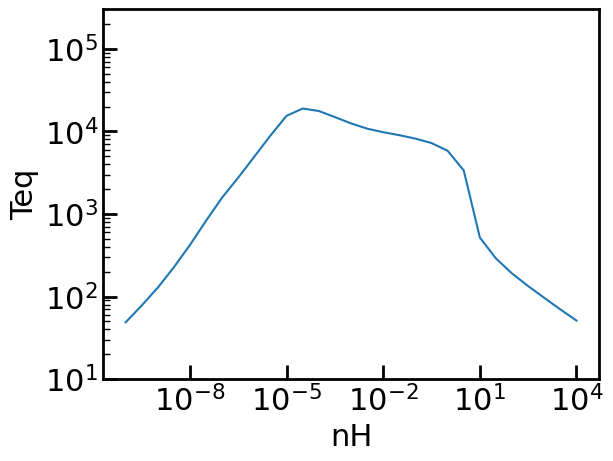

In [29]:
plt.plot(nHbins, Teq)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1.e1,3.e5)
plt.ylabel('Teq')
plt.xlabel('nH')

In [30]:
dlnT_dlnnH = np.gradient(np.log10(Teq), np.log10(nHbins))
interp_dlnT_dlnnH = interp1d(np.log10(nHbins), dlnT_dlnnH, kind="cubic")
interp_logTeq = interp1d(np.log10(nHbins), np.log10(Teq), kind="cubic")

In [31]:
def dlnnH_dr(r, y):
    nH = np.exp(y[0])
    
    g = potential.g(r*un.kpc).cgs.value
    # dlnT_dlnnH = interp_dlnT_dlnnH(np.log10(nH))
    # logT = interp_logTeq(np.log10(nH))
    
    # T =  10. ** logT
    T = Thalo 
    rhs = -(g * mu * m_H * kpc / kb / T)  #/ (1. + dlnT_dlnnH)
    
    return [rhs]

In [32]:
from scipy.integrate import cumulative_trapezoid
r = np.linspace(0.1,rvir,1000)
g = potential.g(r*un.kpc).cgs.value
integrand = -(g * mu * m_H * kpc / kb / Thalo)
I = cumulative_trapezoid(integrand, r, initial=0.0)

In [33]:
rspan = (0.1, rvir)
lnnH_ini =  np.log(0.0002597379104532)
y0 = [lnnH_ini]
sol = solve_ivp(dlnnH_dr, rspan, y0, method='RK45', max_step = 0.1)
r = sol.t
dr = np.diff(r)
rmid = 0.5 * (r[1:] + r[:-1])
nH = np.exp(sol.y[0])
rho = nH * m_H/X
mass = 4. * math.pi * rmid * rmid * dr * kpc**3 * rho[:-1]
total_mass = np.sum(mass)
print('Total mass = %.2e'%(total_mass), ', 0.12 halo mass=%.2e'%(0.12*Mvir.cgs.value))

Total mass = 4.24e+43 , 0.12 halo mass=4.24e+43


ValueError: x and y must have same first dimension, but have shapes (1483,) and (1000,)

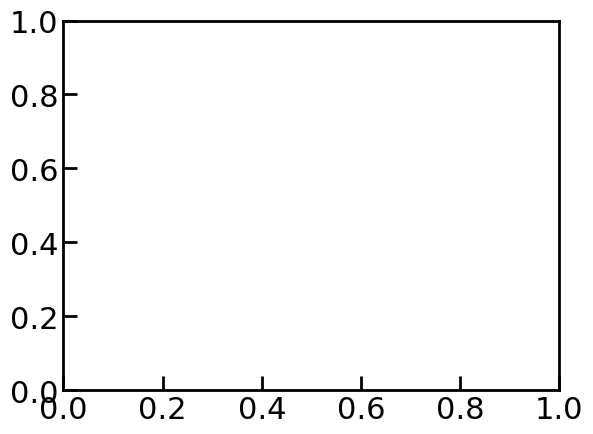

In [17]:
# plt.plot(r, nH)
plt.plot(r, np.exp(I))
plt.yscale('log')
plt.xscale('log')
# plt.ylim(1.e-4,5.e-2)

# plt.xlim(1.0, 10.)